In [1]:
# ==============================================================
# Libries
# ==============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import treecorr

In [2]:
# ==============================================================
# Catalog generators (isotropic and dipolar)
# ==============================================================

def generate_catalog(n_sources, A=0.0, direction=(0, 0), seed=None):
    """
    Generates catalogs: A=0 for isotropy, A>0 for dipole.
    Probability distribution: P(n) ∝ 1 + A (n · d),
    A  dipole amplitude.
    """

    # Create a BitGenerator (rng) with a fixed seed
    rng = np.random.default_rng(seed)
    
    
    # Isotropic case (A = 0)    
    if A == 0:
        ra = 360.0 * rng.random(n_sources)
        u = rng.random(n_sources)
        dec = np.degrees(np.arcsin(2.0 * u - 1.0))
        return pd.DataFrame({"RA": ra, "DEC": dec})
    

    # Dipole case (using rejection sampling)
    ra_d, dec_d = np.deg2rad(direction)
    d = np.array([np.cos(dec_d)*np.cos(ra_d), np.cos(dec_d)*np.sin(ra_d), np.sin(dec_d)])
    
    # Empty lists (recieve RA and DEC coordinates)
    ra_out, dec_out = [], []
    
    # Loop until the desired number of sources is reached
    while len(ra_out) < n_sources:
        
        # Generate random trial coordinates
        r_try = 360.0 * rng.random()
        u_try = 2.0 * rng.random() - 1.0
        d_try = np.degrees(np.arcsin(u_try))
        
        # Convert trial coordinates to a unit vector n
        phi, theta_rad = np.deg2rad(r_try), np.deg2rad(d_try)
        n = np.array([np.cos(theta_rad)*np.cos(phi), np.cos(theta_rad)*np.sin(phi), np.sin(theta_rad)])
        
        # Calculate acceptance probability based on the dipole model
        p = 1.0 + A * np.dot(n, d)

        # Acceptance step (normalized by the maximum possible value of p)
        if rng.random() < p / (1 + abs(A)):
            ra_out.append(r_try); dec_out.append(d_try)
    
    return pd.DataFrame({"RA": ra_out, "DEC": dec_out})

In [3]:
# ==============================================================
# 2pACF Calculation (TreeCorr)
# ==============================================================

def get_2pacf(df_data, df_rand, min_sep=0.1, max_sep=180.0, nbins=20):
    """
    Calculates the Angular Two-Point Angular Correlation Function (2pACF)
    using the Landy-Szalay estimator: w = (DD - 2DR + RR) / RR
    """
    
    # Create TreeCorr catalogs for both observed data and random reference
    cat = treecorr.Catalog(ra=df_data["RA"], dec=df_data["DEC"], ra_units="deg", dec_units="deg")
    rnd = treecorr.Catalog(ra=df_rand["RA"], dec=df_rand["DEC"], ra_units="deg", dec_units="deg")
    
    # Initialize the correlation object with angular separation constraints
    nn = treecorr.NNCorrelation(min_sep=min_sep, max_sep=max_sep, nbins=nbins, sep_units="deg")

    # Create copies of the configuration to store RR and DR pairs
    rr = nn.copy()
    dr = nn.copy()
    
    # Process pair counts: DD, RR, and DR
    nn.process(cat)
    rr.process(rnd)
    dr.process(cat, rnd)
    
    # Compute the correlation function (xi) using the Landy-Szalay formula
    nn.calculateXi(rr=rr, dr=dr)
    return np.exp(nn.meanlogr), nn.xi

In [4]:
# ==============================================================
# Absolute Sum Test (with Linear Rebinning)
# ==============================================================

def get_absolute_sum_bins(theta, w, bin_edges):
    """
    Transforms the original (noisy) 2pACF into a large-scale metric.
    
    The test smoothes noise by averaging within wide angular bins and 
    measures the absolute deviation of this mean from zero (isotropy).
    
    Notes:
    1. np.mean(w[mask]): Calculates the mean correlation in the bin (Rebinning).
       This cancels out random fluctuations and highlights systematic trends.
    2. np.abs(...): Takes the absolute value. Under H0 (isotropy), the mean 
       should be ~0; high |mean| values indicate the presence of anisotropy.
    """
    
    # Initialize list to store absolute sum values
    abs_vals = []
    
    # Iterate through each angular interval (e.g., 0-20, 20-40, 40-60, ...)
    for i in range(len(bin_edges) - 1):
        
        # Mask to select only theta values within the current wide bin
        mask = (theta >= bin_edges[i]) & (theta < bin_edges[i+1])
        
        # Check if there are 2pACF data points within this interval
        if np.any(mask):
            abs_vals.append(np.abs(np.mean(w[mask])))
        else:
            abs_vals.append(0.0)  # If the bin is empty, fill with zero
            
    return np.array(abs_vals)

In [5]:
# ==============================================================
# Benchmark execution and testing
# ==============================================================

N_SOURCES = 5000
N_REALIZATIONS = 500
COARSE_BINS = np.arange(0, 181, 20)
centers = 0.5 * (COARSE_BINS[:-1] + COARSE_BINS[1:])


w_bench = []

# Monte Carlo simulations for the Null Hypothesis (H0: Isotropy)
for i in tqdm(range(N_REALIZATIONS), desc="Calculating Benchmark"):
    
    # Generate an isotropic data catalog and an isotropic random reference
    d_iso = generate_catalog(N_SOURCES, seed=i)
    r_iso = generate_catalog(N_SOURCES, seed=i+500)
    
    # Compute the 2pACF for each realization
    t, w = get_2pacf(d_iso, r_iso)
    w_bench.append(w)

# Convert list to array
w_bench = np.array(w_bench)

# Apply the Absolute Sum Test to all benchmark realizations
abs_bench = np.array([get_absolute_sum_bins(t, wi, COARSE_BINS) for wi in w_bench])


# Generate a catalog with a controlled anisotropy (A=0.06)
cat_signal = generate_catalog(N_SOURCES, A=0.06, seed=999)

# Generate a reference random catalog for the observation
rand_ref = generate_catalog(N_SOURCES, seed=888)

# Compute the 2pACF for the "observed" dipolar catalog
t_sig, w_sig = get_2pacf(cat_signal, rand_ref)

# Apply the Absolute Sum Test to the observed signal
abs_sig = get_absolute_sum_bins(t_sig, w_sig, COARSE_BINS)

Calculating Benchmark:   0%|          | 0/500 [00:00<?, ?it/s]

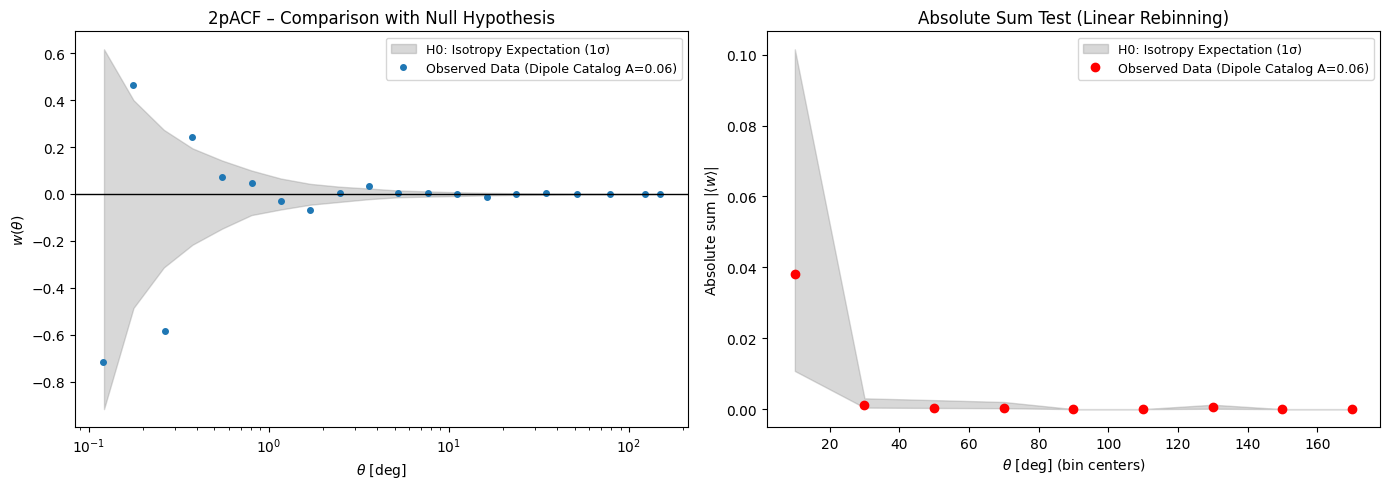

In [6]:
# ==============================================================
# Visualization
# ==============================================================

fig, ax = plt.subplots(1, 2, figsize=(14, 5))


# Plot 1: 2pACF (Points only) 
ax[0].fill_between(t, 
                   np.mean(w_bench, 0) - np.std(w_bench, 0), 
                   np.mean(w_bench, 0) + np.std(w_bench, 0), 
                   color='gray', alpha=0.3, label='H0: Isotropy Expectation (1σ)')

ax[0].plot(t_sig, w_sig, 'o', ms=4, color='tab:blue', label='Observed Data (Dipole Catalog A=0.06)') 
ax[0].set_xscale('log')
ax[0].axhline(0, color='k', lw=1)
ax[0].set_title("2pACF – Comparison with Null Hypothesis")
ax[0].set_xlabel(r"$\theta$ [deg]")
ax[0].set_ylabel(r"$w(\theta)$")
ax[0].legend(fontsize=9)


# Plot 2: Absolute Sum Test
bench_m, bench_s = np.mean(abs_bench, 0), np.std(abs_bench, 0)

ax[1].fill_between(centers, bench_m - bench_s, bench_m + bench_s, color='gray', alpha=0.3, label='H0: Isotropy Expectation (1σ)')
ax[1].plot(centers, abs_sig, 'ro', label='Observed Data (Dipole Catalog A=0.06)')
ax[1].set_title("Absolute Sum Test (Linear Rebinning)")
ax[1].set_xlabel(r"$\theta$ [deg] (bin centers)")
ax[1].set_ylabel(r"Absolute sum $|\langle w \rangle|$")
ax[1].legend(fontsize=9)


plt.tight_layout()
plt.show()